In [17]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

metrics_path = Path("runs/fineweb_60m_53m/metrics.jsonl")

In [18]:
import os
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts import train


In [19]:
#Checking to make sure the records are storing the right things
records = []
with metrics_path.open("r", encoding="utf-8") as file:
    for line in file:
        if (line.strip()):
            record = json.loads(line)
            records.append(record)

print(records[0])
print(records[-1])

{'step': 1, 'tokens': 2048, 'train_loss': 10.904052734375, 'val_loss': None, 'learning_rate': 5e-07, 'gradient_norm': 2.9524152278900146}
{'step': 29295, 'tokens': 59996160, 'train_loss': 4.40119206905365, 'val_loss': None, 'learning_rate': 3e-05, 'gradient_norm': 1.1408884525299072}


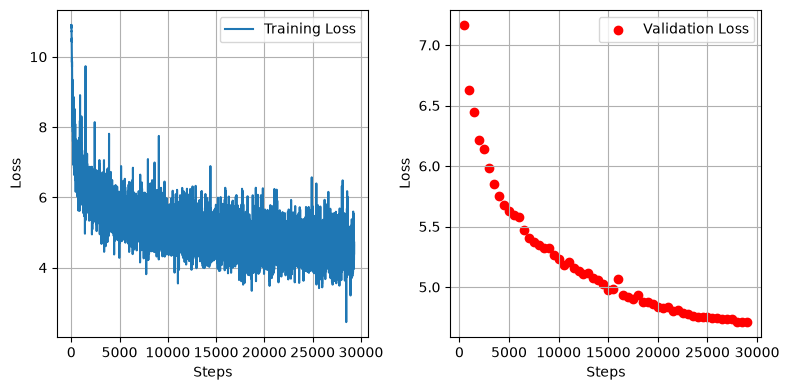

In [21]:
training_steps = [records[i]["step"] for i in range(len(records))]
training_loss = [records[i]["train_loss"] for i in range(len(records))]

validation_steps = [records[i]["step"] for i in range(len(records)) if records[i]["val_loss"] is not None]
validation_loss = [records[i]["val_loss"] for i in range(len(records)) if records[i]["val_loss"] is not None]

fig, (train_ax, val_ax) = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

train_ax.plot(
    training_steps,
    training_loss,
    label="Training Loss"
)
val_ax.scatter(
    validation_steps,
    validation_loss,
    label="Validation Loss",
    color="red"
)
for axis in (train_ax, val_ax):
    axis.grid(True)
    axis.legend()
    axis.set_xlabel("Steps")
    axis.set_ylabel("Loss")
fig.tight_layout()

plt.show()

/tmp/ipykernel_134563/3813394443.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


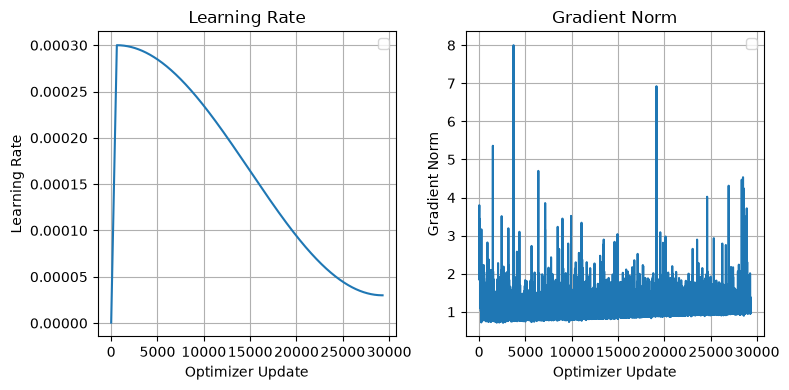

In [22]:
steps = [records[i]["step"] for i in range(len(records))]
learning_rate = [records[i]["learning_rate"] for i in range(len(records))]
gradient_norm = [records[i]["gradient_norm"] for i in range(len(records))]

fig, (lr_ax, grad_ax) = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

lr_ax.plot(steps, learning_rate,)
lr_ax.set(
    title="Learning Rate",
    xlabel="Optimizer Update",
    ylabel="Learning Rate",
)
grad_ax.plot(steps, gradient_norm,)
grad_ax.set(
    title="Gradient Norm",
    xlabel="Optimizer Update",
    ylabel="Gradient Norm",
)
for axis in (lr_ax, grad_ax):
    axis.grid(True)
    axis.legend()
    
fig.tight_layout()

plt.show()